In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
#분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

#회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### Linear Regression(회귀)

In [4]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# 예측한다
y_pred = model.predict(X_test_scaled)
y_pred

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872,  92.1723465 , 258.23238899, 181.33732057,
        90.22411311, 108.63375858,  94.13865744, 168.43486358,
        53.5047888 , 206.63081659, 100.12925869, 130.66657085,
       219.53071499, 250.7803234 , 196.3688346 , 218.57511815,
       207.35050182,  88.48340941,  70.43285917, 188.95914235,
       154.8868162 , 159.36170122, 188.31263363, 180.39094033,
        47.99046561, 108.97453871, 174.77897633,  86.36406656,
       132.95761215, 184.53819483, 173.83220911, 190.35858492,
       124.4156176 , 119.65110656, 147.95168682,  59.05405241,
        71.62331856, 107.68284704, 165.45365458, 155.00975931,
       171.04799096,  61.45761356,  71.66672581, 114.96732206,
        51.57975523, 167.57599528, 152.52291955,  62.95568515,
       103.49741722, 109.20751489, 175.64118426, 154.60296242,
        94.41704366, 210.74209145, 120.2566205 ,  77.61585399,
       187.93203995, 206.49337474, 140.63167076, 105.59

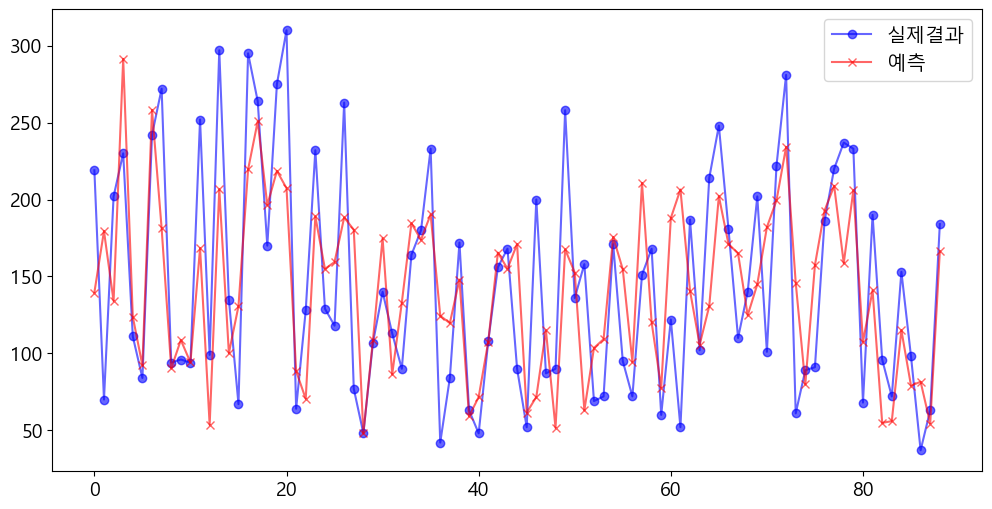

In [14]:
indices = np.arange(len(y_test))

plt.plot(indices, y_test, marker='o', label='실제결과', color='blue', alpha=0.6)
plt.plot(indices, y_pred, marker='x', label='예측', color='red', alpha=0.6)
plt.legend()
plt.show()

In [25]:
# 지표 계산 및 출력
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = model.score(X_test_scaled,y_test)

print(f'MAE : {mae:.4f}')
print(f'MSE : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R^2 : {r2:.4f}')

MAE : 42.7941
MSE : 2900.1936
RMSE : 53.8534
R^2 : 0.4526


### Ridge

In [28]:
# 하이퍼 파라미터
param_grid = {
    # 규제 강도
    'alpha' : [0.001, 0.01, 0.1, 1, 10, 100]
}

In [29]:
# 하이퍼 파라미터 튜닝
model =Ridge()
grid_search = GridSearchCV(model, param_grid=param_grid, cv=5)
grid_search.fit(X_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also

In [32]:
# 최적 모델로 예측
best_ridge = grid_search.best_estimator_
y_pred = best_ridge.predict(X_test_scaled)
y_pred

array([141.15543151, 180.28901425, 139.86949509, 292.19594674,
       122.62851803,  94.72163757, 255.91139287, 186.98253859,
        85.9175148 , 111.72245616,  95.6802089 , 162.33691696,
        63.12106161, 205.60320612, 100.21016019, 132.48886745,
       221.19942123, 246.61695472, 195.1839977 , 214.62280538,
       205.99660208,  89.5950568 ,  73.04384776, 188.24925213,
       155.76911542, 161.94612775, 189.05748688, 177.15976439,
        50.61698083, 111.65045188, 179.41339852,  91.59557844,
       132.21682537, 181.1973565 , 173.29377815, 190.78054117,
       123.51916363, 119.286601  , 146.87373281,  61.57524864,
        75.63402801, 108.73338856, 161.97686293, 150.88261608,
       174.35748947,  65.87283674,  78.54754109, 108.24357177,
        58.59530883, 161.389788  , 155.69283938,  65.92142131,
       113.30415161, 108.7815075 , 170.91694436, 158.5630468 ,
        95.5179121 , 207.22515383, 118.35094766,  70.66730269,
       185.03431733, 201.91515917, 141.50504071, 106.40

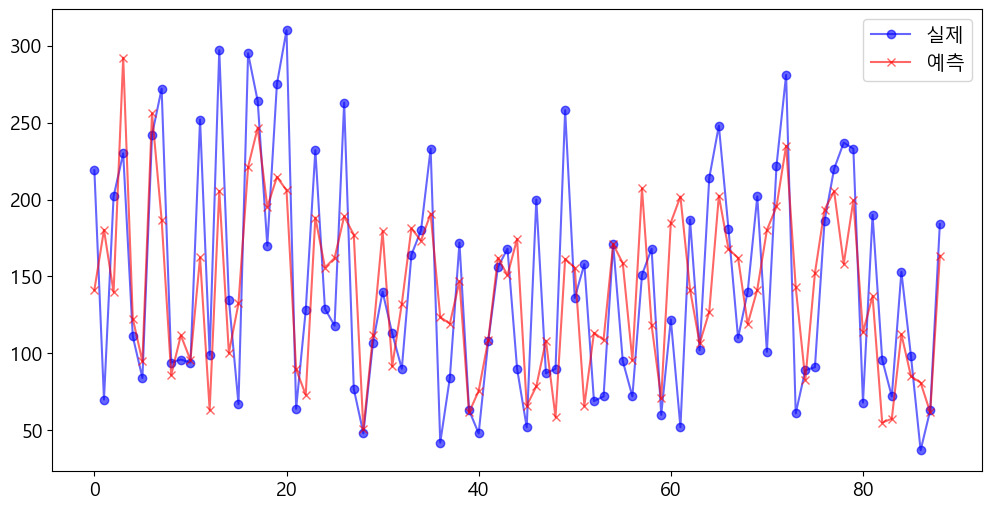

In [33]:
# 시각화
indices = np.arange(len(y_test))
plt.plot(indices, y_test, marker='o', label='실제', color='blue', alpha=0.6)
plt.plot(indices, y_pred, marker='x', label='예측', color='red', alpha=0.6)
plt.legend()
plt.show()

In [35]:
# 지표 출력
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = best_ridge.score(X_test_scaled,y_test)

print(f'최적 파라미터 : {grid_search.best_params_}')
print(f'MAE : {mae:.4f}')
print(f'MSE : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R^2 : {r2:.4f}')

최적 파라미터 : {'alpha': 10}
MAE : 42.8568
MSE : 2875.7787
RMSE : 53.6263
R^2 : 0.4572


### Lasso

In [38]:
# 하이퍼파라미터
param_grid = {
    'alpha' : [0.001, 0.01,0.1,1,10,100]
}

In [41]:
# 하이퍼 파라미터 튜닝
model = Lasso()
grid_search = GridSearchCV(model, param_grid=param_grid, cv=5)
grid_search.fit(X_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also

In [42]:
# 최적의 모델로 예측
best_lasso = grid_search.best_estimator_
y_pred = best_lasso.predict(X_test_scaled)
y_pred

array([144.57023028, 178.81110506, 146.73567504, 280.88957847,
       124.03909694,  97.50249878, 259.67789975, 194.71873825,
        88.3919044 , 118.01101696,  99.19043541, 159.27292039,
        65.55308084, 205.14809807, 101.74721056, 133.22589431,
       222.18296422, 242.78029407, 194.42813441, 213.25114497,
       208.35770698,  90.11574615,  71.05984547, 190.39472477,
       158.87131914, 162.15483057, 190.61003589, 173.36685377,
        51.82544349, 115.67752438, 178.68551235,  92.88560262,
       136.60336668, 179.57402381, 171.21011118, 200.80798743,
       125.65645075, 121.91151049, 145.17830531,  60.59819277,
        72.85152207, 108.69104169, 161.10624053, 144.39331843,
       174.05133453,  67.30989032,  80.11398941, 102.82187412,
        57.69725661, 161.83449653, 156.57888261,  69.9406521 ,
       111.54468605, 106.8109581 , 171.96116585, 160.43315235,
        95.13421852, 207.88273395, 120.57955489,  67.88452473,
       184.96126993, 201.72008257, 144.70280481, 107.34

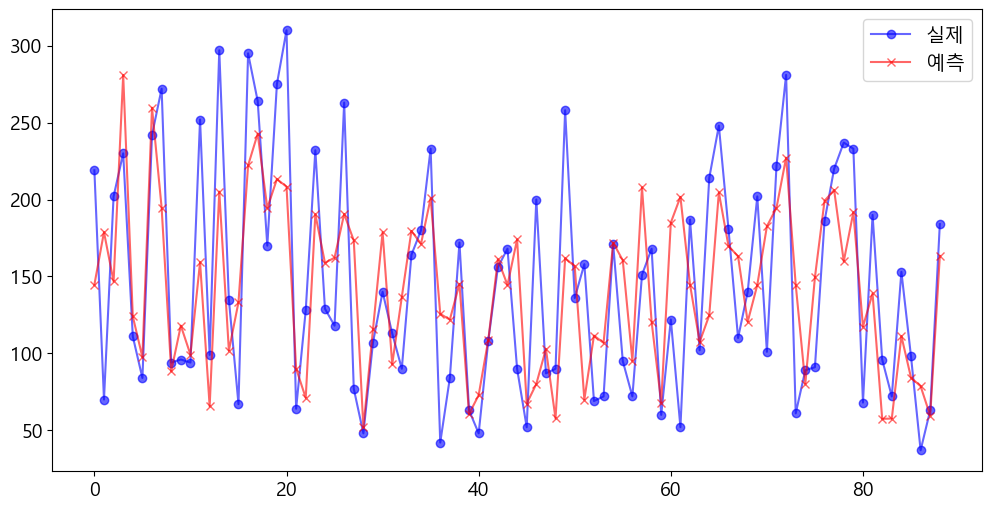

In [43]:
indices = np.arange(len(y_test))
plt.plot(indices, y_test, marker='o', label='실제', color='blue', alpha=0.6 )
plt.plot(indices, y_pred, marker='x', label='예측', color='red', alpha=0.6)
plt.legend()
plt.show()

In [44]:
# 평가지표 출력
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = best_lasso.score(X_test_scaled,y_test)

print(f'최적 파라미터 : {grid_search.best_params_}')
print(f'MAE : {mae:.4f}')
print(f'MSE : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R^2 : {r2:.4f}')

최적 파라미터 : {'alpha': 1}
MAE : 42.8030
MSE : 2824.5681
RMSE : 53.1467
R^2 : 0.4669


### ElasticNet

In [50]:
param_grid = {
    # 규제 강도
    'alpha' : [0.001,0.01,0.1,1,10,100],   
    # 규제 비율 (0이면 릿지, 1이면 라쏘)
    'l1_ratio' : [0, 0.2,0.5,0.7,1.0]
}

In [54]:
# 하이퍼 파라미터 튜닝
model = ElasticNet()
grid_search = GridSearchCV(model, param_grid=param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'l1_ratio': [0, 0.2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [56]:
# 최적의 모델로 예측
best_en = grid_search.best_estimator_
y_pred = best_en.predict(X_test_scaled)
y_pred

array([143.27659079, 178.41214958, 142.48781341, 287.99493172,
       124.79009427,  98.57063953, 251.90794031, 189.06784106,
        88.08300097, 114.85650794,  97.83323048, 158.55291021,
        66.76880599, 205.41618537, 103.25955533, 133.69294755,
       220.58349898, 243.89587292, 192.34918332, 212.33679835,
       202.26296525,  91.97763784,  76.20538158, 187.60848848,
       154.80517024, 162.88227345, 187.78203776, 175.86539549,
        53.58832059, 115.44862831, 179.49092975,  94.58046091,
       133.47873906, 180.50633932, 173.28350961, 189.86060617,
       125.56303797, 122.212541  , 149.44022014,  64.27111102,
        79.85974296, 111.16308891, 160.22769515, 152.12212179,
       173.90402773,  68.85543536,  82.15447716, 107.1540052 ,
        62.57087308, 158.12103212, 154.1849912 ,  68.3994076 ,
       117.31280763, 110.02281169, 170.52519862, 157.15729804,
        98.43890206, 203.90917104, 117.92708938,  70.82951213,
       183.91928728, 197.74883353, 141.42916944, 109.49

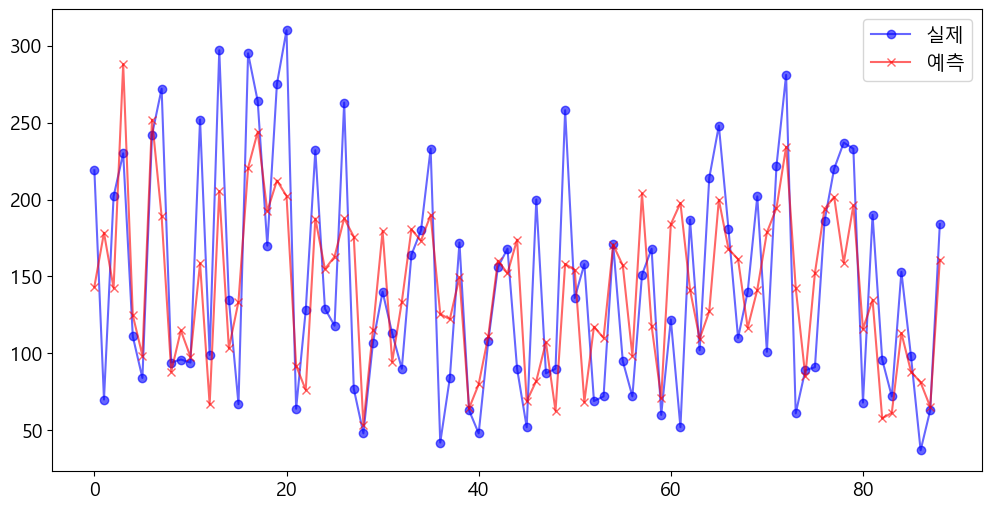

In [58]:
plt.plot(indices,y_test, marker='o', label='실제', color='blue', alpha=0.6)
plt.plot(indices,y_pred, marker='x', label='예측', color='red', alpha=0.6)
plt.legend()
plt.show()

In [62]:
# 지표 출력
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2= best_en.score(X_test_scaled,y_test)

print(f'최적 파라미터 : {grid_search.best_params_}')
print(f'MAE : {mae:.4f}')
print(f'MSE : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R^2 : {r2:.4f}')

최적 파라미터 : {'alpha': 0.1, 'l1_ratio': 0}
MAE : 42.9675
MSE : 2859.9813
RMSE : 53.4788
R^2 : 0.4602


### Logistic Regression (분류)

In [65]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y,random_state=42)

In [67]:
# 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
# 하이퍼 파라미터
param_grid = {
    'C' : [0.01,0.1,1,10,100]
}

In [69]:
# 하이퍼 파라미터 튜닝
model = LogisticRegression(max_iter=5000, solver='saga')
grid_search = GridSearchCV(model, param_grid=param_grid, cv=5)
grid_search.fit(X_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter

In [70]:
# 최적 모델 추출 및 예측
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test_scaled)
y_pred

array([2, 1, 1, 1, 2, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 1, 2, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 1, 2,
       1])

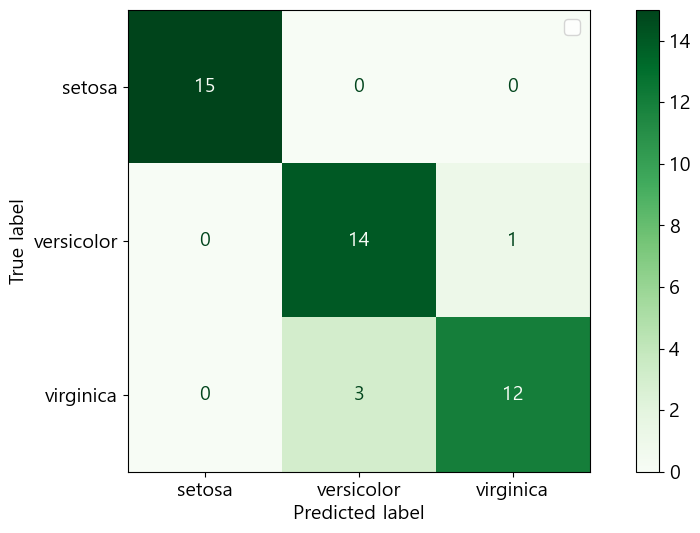

In [75]:
# 시각화
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Greens)
plt.legend()
plt.show()

In [80]:
# 지표 출력
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred, average='macro')
recall = recall_score(y_test,y_pred, average='macro')
f1 = f1_score(y_test,y_pred, average='macro')

print(f'최적 파라미터 : {grid_search.best_params_}')
print(f'accuracy : {accuracy:.4f}')
print(f'precision : {precision:.4f}')
print(f'recall : {recall:.4f}')
print(f'f1 : {f1:.4f}')

최적 파라미터 : {'C': 1}
accuracy : 0.9111
precision : 0.9155
recall : 0.9111
f1 : 0.9107
